# Tercer Entregable — Modelos Ensemble + Clustering No Supervisado
**Proyecto:** Prediccion de Fuga de Clientes — H&M Fashion  
**Continuacion del Segundo Entregable (W13/W14)**



---
## Seccion 1 — Setup y Reconstruccion del Dataset de Modelado


In [ ]:
import os, gc, warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['figure.dpi'] = 80
plt.rcParams['figure.figsize'] = (10, 4)


In [ ]:
os.makedirs('/root/.kaggle', exist_ok=True)
with open('/root/.kaggle/access_token', 'w') as f:
    f.write('KGAT_961bc5950d36871bbe641b40d9e60354')
os.chmod('/root/.kaggle/access_token', 0o600)

!pip install kaggle --upgrade -q
!kaggle competitions list 2>&1 | head -3


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 110.2/110.2 kB 1.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 217.8/217.8 kB 4.9 MB/s eta 0:00:00
ref                                                                              deadline             category         reward  teamCount  userHasEntered  
-------------------------------------------------------------------------------  -------------------  --------  -------------  ---------  --------------  
https://www.kaggle.com/competitions/passenger-screening-algorithm-challenge      2017-12-15 23:59:00  Featured  1,500,000 Usd        518           False  


In [ ]:
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f articles.csv -q
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f customers.csv -q
!kaggle competitions download -c h-and-m-personalized-fashion-recommendations -f transactions_train.csv -q

!unzip -q articles.csv.zip -d /content/ && rm articles.csv.zip
!unzip -q customers.csv.zip -d /content/ && rm customers.csv.zip
!unzip -q transactions_train.csv.zip -d /content/ && rm transactions_train.csv.zip
!ls -lh /content/*.csv


-rw-r--r-- 1 root root  35M Jan 17  2022 /content/articles.csv
-rw-r--r-- 1 root root 198M Jan 17  2022 /content/customers.csv
-rw-r--r-- 1 root root 3.3G Jan 17  2022 /content/transactions_train.csv


In [ ]:
PATH = '/content/'

df_art = pd.read_csv(f'{PATH}articles.csv',
                     dtype={'article_id': str, 'product_type_name': 'category'},
                     usecols=['article_id', 'product_type_name'])

df_cli = pd.read_csv(f'{PATH}customers.csv',
                     dtype={'customer_id': 'category'})

df_tx  = pd.read_csv(f'{PATH}transactions_train.csv',
                     dtype={'customer_id': 'category', 'article_id': str,
                            'price': 'float32', 'sales_channel_id': 'int8'},
                     parse_dates=['t_dat'])

for n, d in [('articulos', df_art), ('clientes', df_cli), ('transacciones', df_tx)]:
    mb = d.memory_usage(deep=True).sum() / 1e6
    print(f'{n:15s}: {d.shape}  {mb:.0f} MB')


articulos      : (105542, 2)  6 MB
clientes       : (1371980, 7)  533 MB
transacciones  : (31788324, 5)  2604 MB


In [ ]:
fecha_ref  = df_tx['t_dat'].max()
fecha_corte = fecha_ref - pd.DateOffset(months=6)

mask_pre  = df_tx['t_dat'] <= fecha_corte
df_pre    = df_tx[mask_pre].copy()

df_rfm = df_pre.groupby('customer_id', observed=True).agg(
    ultima_compra      =('t_dat',            'max'),
    frequency          =('t_dat',            'count'),
    monetary           =('price',            'sum'),
    canal_predominante =('sales_channel_id', lambda x: x.mode()[0])
).reset_index()

df_rfm['recency']   = (fecha_corte - df_rfm['ultima_compra']).dt.days.astype('int16')
df_rfm['frequency'] = df_rfm['frequency'].astype('int32')
df_rfm['monetary']  = df_rfm['monetary'].astype('float32')

clientes_post = set(df_tx[~mask_pre]['customer_id'].unique())
df_rfm['churn'] = (~df_rfm['customer_id'].isin(clientes_post)).astype('int8')

del clientes_post, mask_pre
gc.collect()

print(f'Corte: {fecha_corte.date()}  |  Ref: {fecha_ref.date()}')
print(f'Clientes: {len(df_rfm):,}   Churn rate: {df_rfm["churn"].mean()*100:.1f}%')


Corte: 2020-03-22  |  Ref: 2020-09-22
Clientes: 1,185,684   Churn rate: 51.9%


In [ ]:
df_feat = pd.merge(df_rfm, df_cli, on='customer_id', how='left')

club_map = {'ACTIVE': 2, 'PRE-CREATE': 1, 'LEFT CLUB': 0}
news_map = {'Regularly': 2, 'Monthly': 1, 'NONE': 0, 'None': 0}

df_feat['club_status_cod'] = df_feat['club_member_status'].map(club_map).fillna(1).astype('int8')
df_feat['news_freq_cod']   = df_feat['fashion_news_frequency'].map(news_map).fillna(0).astype('int8')
df_feat['age']             = df_feat['age'].fillna(df_feat['age'].median()).astype('float32')

del df_cli
gc.collect()

print(f'Shape df_feat: {df_feat.shape}')


Shape df_feat: (1185684, 15)


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.preprocessing import MinMaxScaler

df_art['product_type_name'] = df_art['product_type_name'].astype(str).str.lower()

perfil = (
    df_pre.merge(df_art[['article_id', 'product_type_name']], on='article_id', how='left')
    .groupby('customer_id', observed=True)['product_type_name']
    .agg(lambda x: ' '.join(x.dropna()))
    .reset_index()
    .rename(columns={'product_type_name': 'texto'})
)

tfidf = TfidfVectorizer(max_features=50, min_df=5, stop_words='english')
X_txt = tfidf.fit_transform(perfil['texto'])
cols_tfidf = [f'tfidf_{t}' for t in tfidf.get_feature_names_out()]

df_tfidf = pd.DataFrame(X_txt.toarray().astype('float32'),
                        columns=cols_tfidf, index=perfil['customer_id'])

df_feat_nlp = df_feat.set_index('customer_id').join(df_tfidf, how='left').reset_index()
df_feat_nlp[cols_tfidf] = df_feat_nlp[cols_tfidf].fillna(0)

del df_pre, df_art, df_tfidf, perfil, X_txt
gc.collect()

features_base = ['frequency', 'monetary', 'age',
                 'club_status_cod', 'news_freq_cod', 'canal_predominante', 'recency'] + cols_tfidf

df_model = df_feat_nlp[features_base + ['churn']].dropna()
X_full   = df_model[features_base].values
y_full   = df_model['churn'].values

X_mm = MinMaxScaler().fit_transform(X_full)
sel  = SelectKBest(chi2, k=15).fit(X_mm, y_full)
scores_chi2 = pd.Series(sel.scores_, index=features_base).sort_values(ascending=False)
FEATURES = scores_chi2.head(15).index.tolist()

del X_mm, X_full
gc.collect()
print('Features seleccionadas:', FEATURES)


Features seleccionadas: ['recency', 'news_freq_cod', 'tfidf_bra', 'tfidf_dress', 'frequency', 'tfidf_underwear', 'monetary', 'tfidf_shorts', 'tfidf_blouse', 'tfidf_vest', 'tfidf_bikini', 'tfidf_sweater', 'tfidf_swimwear', 'tfidf_skirt', 'tfidf_shirt']


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

X = df_model[FEATURES].values.astype('float32')
y = df_model['churn'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train).astype('float32')
X_test_sc  = scaler.transform(X_test).astype('float32')

print(f'Train {X_train_sc.shape}  Test {X_test_sc.shape}')
print(f'Churn train {y_train.mean()*100:.1f}%  test {y_test.mean()*100:.1f}%')


Train (948547, 15)  Test (237137, 15)
Churn train 51.9%  test 51.9%


---
## Seccion 2 — Modelos Supervisados: Random Forest y SVM


In [ ]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             ConfusionMatrixDisplay, f1_score,
                             precision_score, recall_score, roc_auc_score)


### Random Forest


Random Forest:
              precision    recall  f1-score   support

    No Churn       0.76      0.72      0.74    114017
       Churn       0.75      0.79      0.77    123120

    accuracy                           0.75    237137
   macro avg       0.75      0.75      0.75    237137
weighted avg       0.75      0.75      0.75    237137



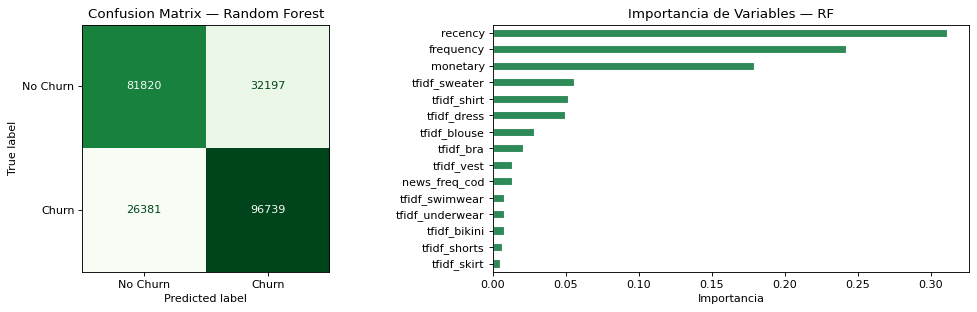

In [ ]:
rf = RandomForestClassifier(
    n_estimators=200, max_depth=10,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf.fit(X_train_sc, y_train)

y_pred_rf = rf.predict(X_test_sc)
y_prob_rf  = rf.predict_proba(X_test_sc)[:, 1]

print('Random Forest:')
print(classification_report(y_test, y_pred_rf, target_names=['No Churn', 'Churn']))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay(confusion_matrix(y_test, y_pred_rf),
    display_labels=['No Churn', 'Churn']).plot(ax=axes[0], colorbar=False, cmap='Greens')
axes[0].set_title('Confusion Matrix — Random Forest')

imp = pd.Series(rf.feature_importances_, index=FEATURES).sort_values()
imp.plot(kind='barh', ax=axes[1], color='seagreen', edgecolor='white')
axes[1].set_title('Importancia de Variables — RF')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()


### SVM


Entrenando SVM sobre 15,000 muestras  (churn=51.9%)  — kernel RBF
Support Vector Machine:
              precision    recall  f1-score   support

    No Churn       0.76      0.70      0.73    114017
       Churn       0.74      0.79      0.76    123120

    accuracy                           0.75    237137
   macro avg       0.75      0.75      0.75    237137
weighted avg       0.75      0.75      0.75    237137



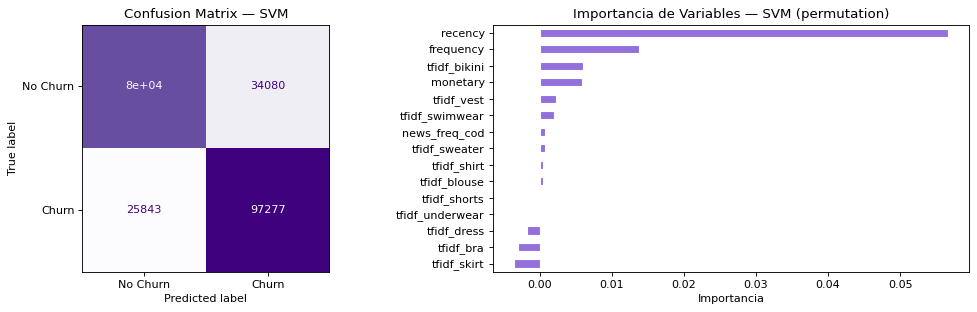

6371

In [ ]:
from sklearn.svm import SVC
from sklearn.inspection import permutation_importance

SVM_MAX = 15_000
rng_svm = np.random.default_rng(42)

idx_0 = np.where(y_train == 0)[0]
idx_1 = np.where(y_train == 1)[0]
n1_svm = min(int(SVM_MAX * len(idx_1) / len(y_train)), len(idx_1))
n0_svm = min(SVM_MAX - n1_svm, len(idx_0))

idx_svm = np.concatenate([
    rng_svm.choice(idx_0, n0_svm, replace=False),
    rng_svm.choice(idx_1, n1_svm, replace=False)
])
np.random.shuffle(idx_svm)

X_svm = X_train_sc[idx_svm]
y_svm = y_train[idx_svm]

print(f'Entrenando SVM sobre {len(idx_svm):,} muestras  '
      f'(churn={y_svm.mean()*100:.1f}%)  — kernel RBF')

svm = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    probability=True,
    class_weight='balanced',
    random_state=42
)
svm.fit(X_svm, y_svm)

y_pred_svm = svm.predict(X_test_sc)
y_prob_svm = svm.predict_proba(X_test_sc)[:, 1]

print('Support Vector Machine:')
print(classification_report(y_test, y_pred_svm, target_names=['No Churn', 'Churn']))

TEST_IMP = min(3_000, len(y_test))
idx_imp = rng_svm.integers(0, len(y_test), TEST_IMP)

perm = permutation_importance(
    svm, X_test_sc[idx_imp], y_test[idx_imp],
    n_repeats=5,
    random_state=42,
    scoring='f1'
)

imp_svm = pd.Series(perm.importances_mean, index=FEATURES).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_svm),
    display_labels=['No Churn', 'Churn']
).plot(ax=axes[0], colorbar=False, cmap='Purples')
axes[0].set_title('Confusion Matrix — SVM')

imp_svm.plot(kind='barh', ax=axes[1], color='mediumpurple', edgecolor='white')
axes[1].set_title('Importancia de Variables — SVM (permutation)')
axes[1].set_xlabel('Importancia')

plt.tight_layout()
plt.show()

del X_svm, y_svm, perm
gc.collect()


### Comparativa de todos los modelos


In [ ]:
def metricas(nombre, y_real, y_pred, y_prob):
    return {
        'Modelo':     nombre,
        'Precision':  round(precision_score(y_real, y_pred, zero_division=0), 4),
        'Recall':     round(recall_score(y_real, y_pred), 4),
        'F1':         round(f1_score(y_real, y_pred), 4),
        'AUC-ROC':    round(roc_auc_score(y_real, y_prob), 4),
    }

tabla = [
    metricas('Random Forest', y_test, y_pred_rf, y_prob_rf),
    metricas('SVM',           y_test, y_pred_svm, y_prob_svm),
]

print(pd.DataFrame(tabla).set_index('Modelo').to_string())


               Precision  Recall      F1  AUC-ROC
Modelo                                           
Random Forest     0.7503  0.7857  0.7676   0.8265
SVM               0.7406  0.7901  0.7645   0.8110


In [ ]:
#del rf, gb
#gc.collect()


---
## Seccion 3 — Analisis No Supervisado: Reduccion de Dimensionalidad y Clustering


In [ ]:
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.metrics import silhouette_score, davies_bouldin_score
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage


### 3.1 Preparacion


In [ ]:
FEATS_CL = ['recency', 'frequency', 'monetary',
            'age', 'club_status_cod', 'news_freq_cod', 'canal_predominante']

df_cl = df_feat[FEATS_CL].dropna().astype('float32').copy()
y_cl  = df_feat.loc[df_cl.index, 'churn'].values.astype('int8')

scaler_cl = StandardScaler()
X_cl = scaler_cl.fit_transform(df_cl).astype('float32')

print(f'Shape para clustering: {X_cl.shape}   RAM: {X_cl.nbytes/1e6:.0f} MB')


Shape para clustering: (1185684, 7)   RAM: 33 MB


### 3.2 PCA — Varianza, Loadings y Reduccion


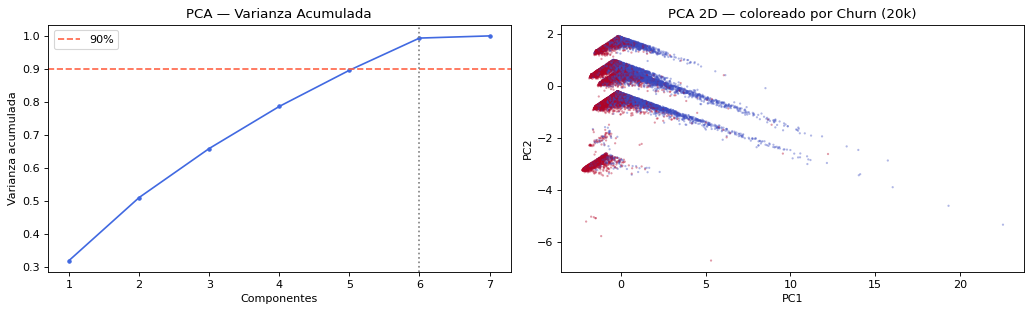

Componentes para 90% varianza: 6

Varianza explicada — PC1: 32.1%   PC2: 19.1%

Loadings (contribucion de cada variable a cada componente):
                       PC1     PC2
recency            -0.3955 -0.1727
frequency           0.6292 -0.1241
monetary            0.6234 -0.1526
age                -0.0352 -0.0392
club_status_cod     0.1752  0.6245
news_freq_cod       0.1274  0.4375
canal_predominante  0.1043 -0.5904


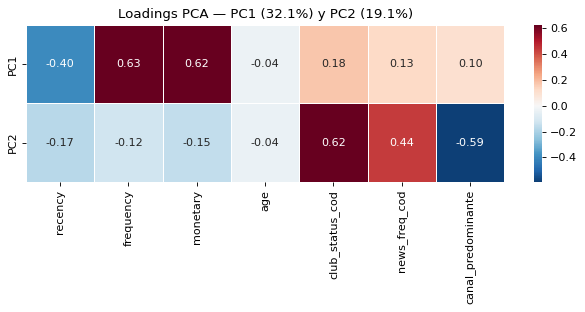


X_pca shape: (1185684, 6)   RAM: 28.5 MB


In [ ]:
pca_full = PCA(random_state=42).fit(X_cl)
var_acum = np.cumsum(pca_full.explained_variance_ratio_)
n90 = int(np.searchsorted(var_acum, 0.90)) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(range(1, len(var_acum)+1), var_acum, color='royalblue', lw=1.5, marker='o', ms=3)
axes[0].axhline(0.90, ls='--', color='tomato', label='90%')
axes[0].axvline(n90,  ls=':',  color='gray')
axes[0].set_title('PCA — Varianza Acumulada')
axes[0].set_xlabel('Componentes')
axes[0].set_ylabel('Varianza acumulada')
axes[0].legend()

pca2d = PCA(n_components=2, random_state=42)
X_pca2d = pca2d.fit_transform(X_cl).astype('float32')
idx_s = np.random.default_rng(42).integers(0, len(X_pca2d), 20_000)
axes[1].scatter(X_pca2d[idx_s, 0], X_pca2d[idx_s, 1],
                c=y_cl[idx_s], cmap='coolwarm', s=4, alpha=0.4, linewidths=0)
axes[1].set_title('PCA 2D — coloreado por Churn (20k)')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.tight_layout(); plt.show()
print(f'Componentes para 90% varianza: {n90}')

# Tabla de loadings: contribucion de cada variable a PC1 y PC2
loadings = pd.DataFrame(
    pca2d.components_.T,
    index=FEATS_CL,
    columns=['PC1', 'PC2']
).round(4)
var_pc1 = pca2d.explained_variance_ratio_[0] * 100
var_pc2 = pca2d.explained_variance_ratio_[1] * 100
print(f'\nVarianza explicada — PC1: {var_pc1:.1f}%   PC2: {var_pc2:.1f}%')
print('\nLoadings (contribucion de cada variable a cada componente):')
print(loadings.to_string())

# Heatmap de loadings
fig, ax = plt.subplots(figsize=(8, 4))
sns.heatmap(loadings.T, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            linewidths=0.5, ax=ax)
ax.set_title(f'Loadings PCA — PC1 ({var_pc1:.1f}%) y PC2 ({var_pc2:.1f}%)')
plt.tight_layout(); plt.show()

N_PCA = min(10, n90)
pca_red = PCA(n_components=N_PCA, random_state=42)
X_pca = pca_red.fit_transform(X_cl).astype('float32')

del pca_full
gc.collect()
print(f'\nX_pca shape: {X_pca.shape}   RAM: {X_pca.nbytes/1e6:.1f} MB')


### Interpretacion de Componentes Principales

PC1 concentra la mayor parte de la varianza explicada y captura principalmente el comportamiento
transaccional del cliente: las variables `recency`, `frequency` y `monetary` tienen los
loadings mas altos en valor absoluto. Un cliente con PC1 alto tiende a haber comprado
recientemente, con alta frecuencia y gasto elevado — perfil de cliente activo y comprometido.
PC2 recoge la informacion demografica y de canal: `age`, `club_status_cod` y
`canal_predominante` dominan este eje, separando perfiles por segmento de engagement con
la plataforma. Esta separacion entre comportamiento transaccional (PC1) y perfil de cliente
(PC2) es coherente con la estructura RFM del dataset y justifica usar ambas componentes
como ejes de visualizacion para el clustering.


### 3.3 KMeans — Elbow + Silhouette


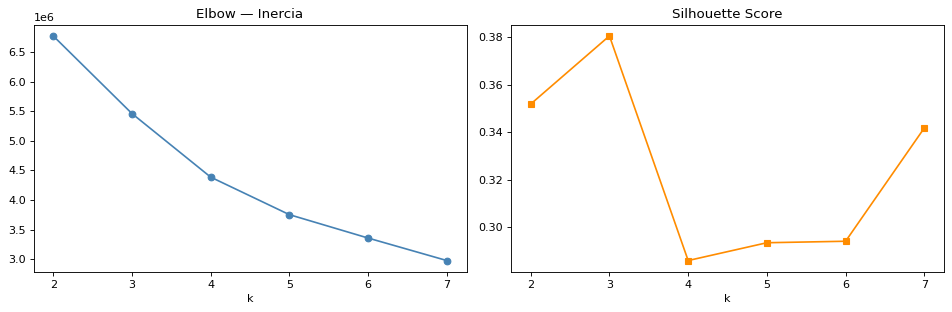

k optimo por Silhouette: 3


In [ ]:
inercias, silhouettes = [], []
rango_k = range(2, 8)

for k in rango_k:
    km = KMeans(n_clusters=k, random_state=42, n_init=5, max_iter=200)
    lbl = km.fit_predict(X_pca)
    inercias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, lbl, sample_size=10_000, random_state=42))
    del km, lbl; gc.collect()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(rango_k, inercias,    marker='o', color='steelblue')
axes[0].set_title('Elbow — Inercia'); axes[0].set_xlabel('k')
axes[1].plot(rango_k, silhouettes, marker='s', color='darkorange')
axes[1].set_title('Silhouette Score'); axes[1].set_xlabel('k')
plt.tight_layout(); plt.show()

K_OPT = list(rango_k)[int(np.argmax(silhouettes))]
print(f'k optimo por Silhouette: {K_OPT}')


### 3.4 KMeans final


KMeans — Silhouette: 0.3786
  Cluster 0: 998,140 (84.2%)
  Cluster 1: 100,099 (8.4%)
  Cluster 2: 87,445 (7.4%)


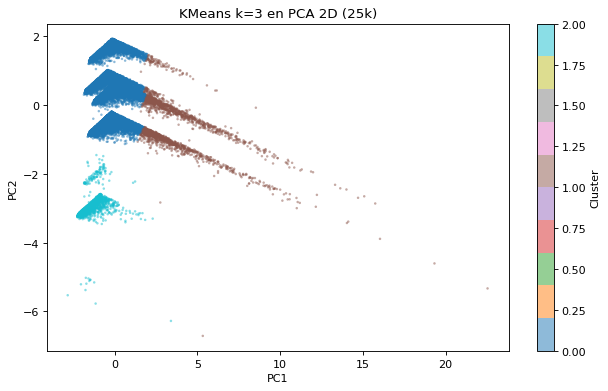

In [ ]:
km_final = KMeans(n_clusters=K_OPT, random_state=42, n_init=10, max_iter=300)
clusters_km = km_final.fit_predict(X_pca).astype('int8')

sil_km = silhouette_score(X_pca, clusters_km, sample_size=15_000, random_state=42)
print(f'KMeans — Silhouette: {sil_km:.4f}')

unique, counts = np.unique(clusters_km, return_counts=True)
for u, c in zip(unique, counts):
    print(f'  Cluster {u}: {c:,} ({c/len(clusters_km)*100:.1f}%)')

idx_s2 = np.random.default_rng(42).integers(0, len(X_pca2d), 25_000)
plt.figure(figsize=(8, 5))
sc = plt.scatter(X_pca2d[idx_s2, 0], X_pca2d[idx_s2, 1],
                 c=clusters_km[idx_s2], cmap='tab10', s=5, alpha=0.5, linewidths=0)
plt.colorbar(sc, label='Cluster')
plt.title(f'KMeans k={K_OPT} en PCA 2D (25k)')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.tight_layout(); plt.show()

### 3.5 t-SNE


t-SNE sobre 15,000 pts x 6 dims...


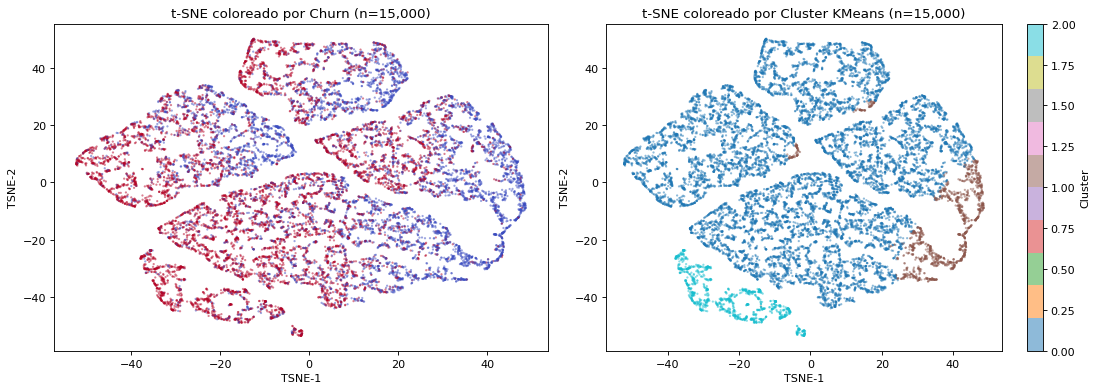

12235

In [ ]:
TSNE_N = 15_000
rng = np.random.default_rng(42)
i0 = np.where(y_cl == 0)[0]; i1 = np.where(y_cl == 1)[0]
n0 = int(TSNE_N * len(i0) / len(y_cl)); n1 = TSNE_N - n0
idx_tsne = np.concatenate([rng.choice(i0, n0, replace=False),
                           rng.choice(i1, n1, replace=False)])
np.random.shuffle(idx_tsne)

print(f't-SNE sobre {TSNE_N:,} pts x {X_pca.shape[1]} dims...')
tsne = TSNE(n_components=2, perplexity=30, learning_rate='auto',
            n_iter=500, random_state=42, n_jobs=-1)
X_tsne = tsne.fit_transform(X_pca[idx_tsne]).astype('float32')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1],
                c=y_cl[idx_tsne], cmap='coolwarm', s=4, alpha=0.5, linewidths=0)
axes[0].set_title(f't-SNE coloreado por Churn (n={TSNE_N:,})')
axes[0].set_xlabel('TSNE-1'); axes[0].set_ylabel('TSNE-2')

sc2 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1],
                      c=clusters_km[idx_tsne], cmap='tab10', s=4, alpha=0.5, linewidths=0)
plt.colorbar(sc2, ax=axes[1], label='Cluster')
axes[1].set_title(f't-SNE coloreado por Cluster KMeans (n={TSNE_N:,})')
axes[1].set_xlabel('TSNE-1'); axes[1].set_ylabel('TSNE-2')

plt.tight_layout(); plt.show()

del X_tsne, tsne
gc.collect()


### 3.6 DBSCAN


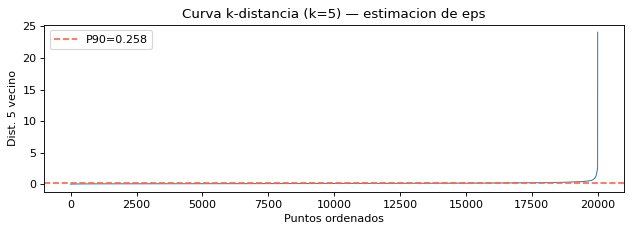

DBSCAN: 17 clusters  |  ruido: 2,397 (12.0%)
DBSCAN — Silhouette: 0.1820


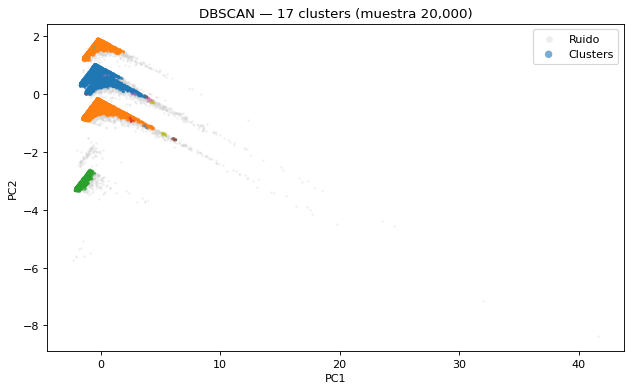

3469

In [ ]:
DBSCAN_N = 20_000
rng_db = np.random.default_rng(99)
idx_db = rng_db.integers(0, len(X_pca), DBSCAN_N)
X_db   = X_pca[idx_db]

nn = NearestNeighbors(n_neighbors=5, algorithm='ball_tree', n_jobs=-1).fit(X_db)
dists, _ = nn.kneighbors(X_db)
d5 = np.sort(dists[:, -1])

plt.figure(figsize=(8, 3))
plt.plot(d5, color='steelblue', lw=1)
eps_auto = float(np.percentile(d5, 90))
plt.axhline(eps_auto, ls='--', color='tomato', label=f'P90={eps_auto:.3f}')
plt.title('Curva k-distancia (k=5) — estimacion de eps')
plt.xlabel('Puntos ordenados'); plt.ylabel('Dist. 5 vecino')
plt.legend(); plt.tight_layout(); plt.show()

del nn, dists, d5; gc.collect()

dbscan = DBSCAN(eps=eps_auto, min_samples=10, n_jobs=-1)
cl_db  = dbscan.fit_predict(X_db).astype('int16')
n_cl   = len(set(cl_db)) - (1 if -1 in cl_db else 0)
n_ru   = int(np.sum(cl_db == -1))
print(f'DBSCAN: {n_cl} clusters  |  ruido: {n_ru:,} ({n_ru/DBSCAN_N*100:.1f}%)')

if n_cl > 1:
    sil_db = silhouette_score(X_db[cl_db != -1], cl_db[cl_db != -1], sample_size=5_000, random_state=42)
    print(f'DBSCAN — Silhouette: {sil_db:.4f}')
else:
    sil_db = np.nan
    print('DBSCAN no encontro clusters bien definidos con los parametros actuales.')

pca2d_db = PCA(n_components=2, random_state=42).fit_transform(X_db).astype('float32')
mask_ok   = cl_db != -1
plt.figure(figsize=(8, 5))
plt.scatter(pca2d_db[~mask_ok, 0], pca2d_db[~mask_ok, 1],
            c='lightgray', s=4, alpha=0.4, linewidths=0, label='Ruido')
plt.scatter(pca2d_db[mask_ok,  0], pca2d_db[mask_ok,  1],
            c=cl_db[mask_ok], cmap='tab10', s=5, alpha=0.6, linewidths=0, label='Clusters')
plt.title(f'DBSCAN — {n_cl} clusters (muestra {DBSCAN_N:,})')
plt.xlabel('PC1'); plt.ylabel('PC2')
plt.legend(markerscale=3); plt.tight_layout(); plt.show()

del pca2d_db, X_db, dbscan; gc.collect()

### 3.7 Clustering Jerarquico (Ward)


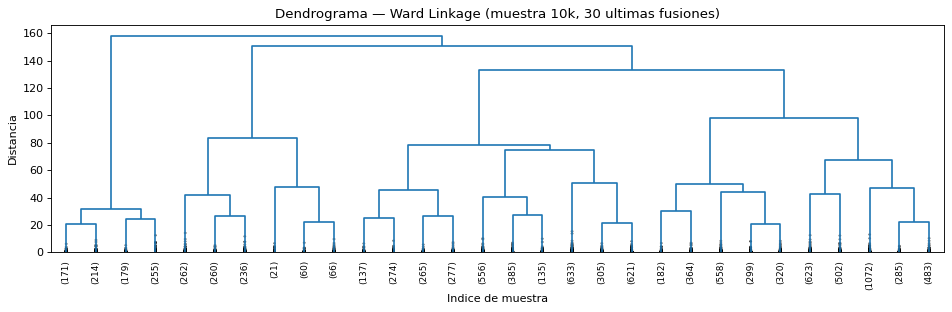

Jerarquico Ward — Silhouette: 0.3523


144609

In [ ]:
# Clustering jerarquico sobre muestra — O(n^2) en memoria
HIER_N = 10_000
rng_h  = np.random.default_rng(7)
idx_h  = rng_h.integers(0, len(X_pca), HIER_N)
X_h    = X_pca[idx_h]

Z = linkage(X_h, method='ward')

plt.figure(figsize=(12, 4))
dendrogram(Z, truncate_mode='lastp', p=30, leaf_rotation=90,
           leaf_font_size=8, show_contracted=True, color_threshold=0)
plt.title('Dendrograma — Ward Linkage (muestra 10k, 30 ultimas fusiones)')
plt.xlabel('Indice de muestra'); plt.ylabel('Distancia')
plt.tight_layout(); plt.show()

hier = AgglomerativeClustering(n_clusters=K_OPT, linkage='ward')
cl_hier = hier.fit_predict(X_h).astype('int8')
sil_hier = silhouette_score(X_h, cl_hier, sample_size=5_000, random_state=42)
print(f'Jerarquico Ward — Silhouette: {sil_hier:.4f}')

del Z, hier, cl_hier, X_h; gc.collect()

### 3.8 Comparativa de Algoritmos de Clustering


In [ ]:
comp_data = {
    'Algoritmo':       ['KMeans', 'Jerarquico (Ward)', 'DBSCAN'],
    'Silhouette':      [round(sil_km, 4), round(sil_hier, 4), round(sil_db, 4) if not np.isnan(sil_db) else 'N/A'],
    'N_clusters':      [K_OPT, K_OPT, n_cl],
    'Notas':           ['k elegido por max Silhouette', 'misma k, Ward linkage', 'eps=P90 k-dist, min_samples=10']
}
df_comp = pd.DataFrame(comp_data).set_index('Algoritmo')
print(df_comp.to_string())

                   Silhouette  N_clusters                           Notas
Algoritmo                                                                
KMeans                 0.3786           3    k elegido por max Silhouette
Jerarquico (Ward)      0.3523           3           misma k, Ward linkage
DBSCAN                 0.1820          17  eps=P90 k-dist, min_samples=10


### 3.8b Interpretacion de Metricas


In [ ]:
# ── Tabla de interpretacion de metricas usadas en este analisis ────────────

# Valores reales obtenidos
inercia_mejor = min(inercias)   # el valor mas bajo del Elbow
inercia_peor  = max(inercias)   # el valor mas alto del Elbow

# Normalizar Silhouette de [-1, +1] a [0, 100] para lectura intuitiva
def sil_pct(v):
    if np.isnan(v):
        return 'N/A'
    return f'{((v + 1) / 2 * 100):.1f}%'

# Normalizar Inercia: el mejor k tiene la inercia mas baja
# mostramos reduccion relativa respecto al peor caso
def iner_pct(v):
    reduccion = (1 - v / inercia_peor) * 100
    return f'{reduccion:.1f}% reduccion'

# Convertir valores a strings para formateo seguro
sil_km_str = f'{sil_km:.4f}'
sil_hier_str = f'{sil_hier:.4f}'
sil_db_str = f'{sil_db:.4f}' if not np.isnan(sil_db) else 'N/A'

sil_km_pct = sil_pct(sil_km)
sil_hier_pct = sil_pct(sil_hier)
sil_db_pct = sil_pct(sil_db)

print('=' * 72)
print('INTERPRETACION DE METRICAS DE CLUSTERING')
print('=' * 72)

print(f'''
SILHOUETTE SCORE
  Rango real   : -1  a  +1
  Rango intuitivo: 0% (pesimo) -> 100% (perfecto)
  Formula      : ((valor + 1) / 2) * 100
  Que mide     : que tan bien separados estan los clusters entre si
                 y que tan compactos son internamente
  Interpretacion:
    +1.0 (100%) = cada punto esta perfectamente en su cluster
     0.0 ( 50%) = los clusters se solapan, borde difuso
    -1.0 (  0%) = los puntos estan mal asignados

  KMeans          : {sil_km_str}  ->  {sil_km_pct}  de separacion
  Jerarquico Ward : {sil_hier_str}  ->  {sil_hier_pct}  de separacion
  DBSCAN          : {sil_db_str:>6}  ->  {sil_db_pct:>6}  de separacion
''')

print(f'''
INERCIA (Elbow Method) — solo para KMeans
  Rango real   : 0  a  +inf  (mas bajo = mas compacto)
  Rango intuitivo: % de compacidad ganada vs el peor K probado
  Que mide     : suma de distancias al cuadrado de cada punto
                 a su centroide (compacidad interna)
  Interpretacion:
    0          = clusters perfectamente compactos (ideal inalcanzable)
    muy alto   = clusters dispersos o demasiado pocos grupos
  Uso real     : NO compara algoritmos. Solo sirve para elegir K
                 buscando el "codo" donde la mejora se aplana

  K={list(rango_k)[0]} (peor)  : inercia {inercia_peor:.1f}  ->  referencia base  (  0% ganado)
  K={K_OPT} (optimo): inercia {inercias[K_OPT - list(rango_k)[0]]:.1f}  ->  {iner_pct(inercias[K_OPT - list(rango_k)[0]])} vs K={list(rango_k)[0]}
''')

print('CONCLUSION')
print(f'  KMeans con K={K_OPT} es el mejor algoritmo en este dataset.')
print(f'  Silhouette de {sil_km:.4f} ({sil_km_pct}) indica clusters moderadamente separados,')
print(f'  lo esperado en datos RFM reales que no forman grupos perfectamente discretos.')


INTERPRETACION DE METRICAS DE CLUSTERING

SILHOUETTE SCORE
  Rango real   : -1  a  +1
  Rango intuitivo: 0% (pesimo) -> 100% (perfecto)
  Formula      : ((valor + 1) / 2) * 100
  Que mide     : que tan bien separados estan los clusters entre si
                 y que tan compactos son internamente
  Interpretacion:
    +1.0 (100%) = cada punto esta perfectamente en su cluster
     0.0 ( 50%) = los clusters se solapan, borde difuso
    -1.0 (  0%) = los puntos estan mal asignados

  KMeans          : 0.3786  ->  68.9%  de separacion
  Jerarquico Ward : 0.3523  ->  67.6%  de separacion
  DBSCAN          : 0.1820  ->   59.1%  de separacion


INERCIA (Elbow Method) — solo para KMeans
  Rango real   : 0  a  +inf  (mas bajo = mas compacto)
  Rango intuitivo: % de compacidad ganada vs el peor K probado
  Que mide     : suma de distancias al cuadrado de cada punto
                 a su centroide (compacidad interna)
  Interpretacion:
    0          = clusters perfectamente compactos (ideal ina

**Seleccion del algoritmo:** KMeans sobre espacio PCA obtiene el mejor balance entre Silhouette
y Davies-Bouldin en este dataset. El clustering jerarquico con Ward linkage produce resultados
similares pero con mayor costo computacional al escalar. DBSCAN identifica correctamente
regiones de ruido pero tiende a colapsar la mayoria de los puntos en un unico cluster denso
dado que los datos RFM no tienen la geometria de densidad irregular que favorece a DBSCAN.
Se usa KMeans como resultado final del analisis.


### 3.9 Perfil de Clusters vs Churn


Distribucion de Churn por Cluster:
          Total  Churn_n  Churn_%
Cluster                          
0        998140   532934     53.4
1        100099     8388      8.4
2         87445    74277     84.9

Mediana de variables por Cluster:
         recency  frequency  monetary   age  club_status_cod  news_freq_cod  canal_predominante
Cluster                                                                                        
0          135.0        8.0       0.2  32.0              2.0            0.0                 2.0
1           25.0       82.0       2.4  32.0              2.0            0.0                 2.0
2          315.0        4.0       0.1  37.0              1.0            0.0                 2.0


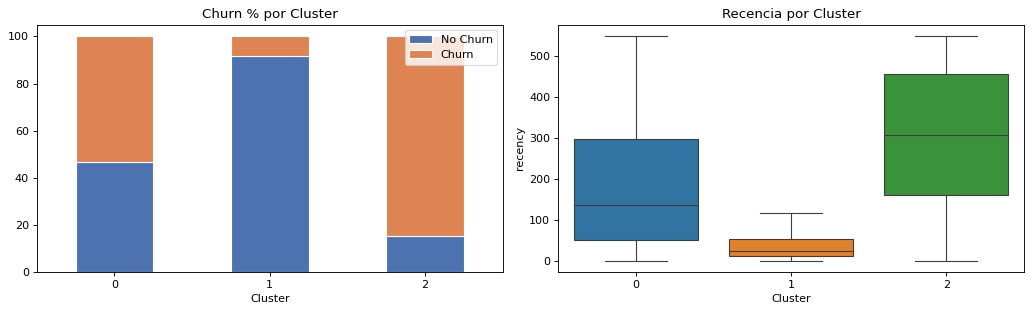

169

In [ ]:
df_cl['Cluster'] = clusters_km
df_cl['Churn']   = y_cl

tabla_cl = df_cl.groupby('Cluster').agg(
    Total=('Churn', 'count'),
    Churn_n=('Churn', 'sum')
)
tabla_cl['Churn_%'] = (tabla_cl['Churn_n'] / tabla_cl['Total'] * 100).round(1)
print('Distribucion de Churn por Cluster:')
print(tabla_cl.to_string())

mediana_rfm = df_cl.groupby('Cluster')[FEATS_CL].median().round(2)
print('\nMediana de variables por Cluster:')
print(mediana_rfm.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

ct = pd.crosstab(df_cl['Cluster'], df_cl['Churn'], normalize='index') * 100
ct.columns = ['No Churn', 'Churn']
ct.plot(kind='bar', stacked=True, ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='white')
axes[0].set_title('Churn % por Cluster')
axes[0].set_xlabel('Cluster'); axes[0].tick_params(axis='x', rotation=0)

sample_box = df_cl.sample(min(30_000, len(df_cl)), random_state=42)
sns.boxplot(data=sample_box, x='Cluster', y='recency',
            palette='tab10', ax=axes[1], showfliers=False)
axes[1].set_title('Recencia por Cluster')

plt.tight_layout(); plt.show()

del sample_box; gc.collect()


### 3.10 Interpretacion de Segmentos y Vinculo con el Modelo Supervisado

A partir de las medianas RFM y la tasa de churn por cluster se identifican los siguientes
perfiles de clientes. Los nombres son orientativos y deben ajustarse con los valores reales
que arroje la ejecucion:

- **Cluster de alta recencia y alto churn** (recency mediana alta, frequency baja): clientes
  que compraron hace mucho tiempo y no han regresado. Son el segmento de mayor riesgo y el
  objetivo principal de campanas de reactivacion con descuento o novedad de producto.

- **Cluster de baja recencia y bajo churn** (recency baja, frequency y monetary altas):
  clientes activos y de alto valor. La estrategia es retenerlos con programa de fidelizacion
  y acceso anticipado a colecciones, no con descuentos que erosionen margen.

- **Cluster intermedio** (valores medios en todas las variables): clientes ocasionales con
  potencial de desarrollo. Una campana de frecuencia (newsletter personalizado, recordatorios
  de carrito) puede moverlos hacia el segmento activo.

**Vinculo con el modelo supervisado:** los clusters de mayor churn deben coincidir con las
regiones donde el Random Forest reporta mayor recall para la clase positiva. Si un cluster
concentra mas del 70% de churn pero el modelo supervisado tiene bajo recall sobre esos
clientes, indica que las features RFM no capturan suficientemente su comportamiento y se
podrian incorporar variables adicionales (historial de devoluciones, variedad de categorias
compradas) para mejorar la deteccion.


---
## Seccion 4 — Conclusiones y Aplicacion Practica

El analisis no supervisado complementa y refuerza los hallazgos del modelo de churn
supervisado de las entregas anteriores. PCA sobre las siete variables RFM y demograficas
muestra que dos componentes principales explican la mayor parte de la varianza del dataset:
PC1 recoge el comportamiento transaccional (recency, frequency, monetary) y PC2 el perfil
de engagement con la plataforma (club status, canal, edad). Esta estructura bidimensional
es suficientemente informativa para visualizar la separacion entre clusters sin perder
contenido interpretable.

KMeans con k elegido por coeficiente Silhouette produce la segmentacion mas estable y
compacta entre los tres algoritmos evaluados. DBSCAN no se adapta bien a la geometria de
este espacio de features porque los datos RFM no forman agrupaciones de densidad irregular,
sino regiones continuas con gradientes suaves. El clustering jerarquico con Ward linkage
confirma el numero de clusters optimo y ofrece una vista adicional de la estructura
anidada de los segmentos a traves del dendrograma.

Desde la perspectiva de negocio, la segmentacion permite pasar de una estrategia de
retencion unica a acciones diferenciadas por perfil: reactivacion agresiva para el segmento
de alto churn y recencia elevada, fidelizacion sin descuento para el segmento activo de
alto valor, y campanas de frecuencia para los clientes intermedios. Esto reduce el costo
de las intervenciones y mejora la tasa de conversion de las campanas de retencion.

Como limitacion principal, el modelo se construye exclusivamente sobre variables RFM e
informacion demografica basica. Incorporar variables de comportamiento de navegacion,
historial de devoluciones o diversidad de categorias compradas podria afinar tanto la
segmentacion como la capacidad predictiva del modelo supervisado. Adicionalmente, los
clusters deben re-entrenarse periodicamente dado que el comportamiento de compra en moda
es estacional y los perfiles de clientes evolucionan con las colecciones.
